In [2]:
import pandas as pd

In [3]:
df1 = pd.read_csv(
    "../../datasets/10 обычных шагов 2.csv",
    sep=";",
    header=None,
    engine="python"
)

df1 = df1.dropna(axis=1, how="all")

In [56]:
df1.columns = [
    "hz",
    "ch1","ch2","ch3","ch4",
    "ch5","ch6","ch7","ch8"
]

In [57]:
df1.head()

,hz,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8
0,30752183,7,-3,-230,-507,-260,2,-178,-295
1,30753288,-3,-1,-235,-508,-272,-3,-152,-304
2,30754395,4,4,-222,-392,-276,4,-149,-283
3,30755516,-2,11,-226,-521,-285,7,-104,-300
4,30756612,-11,10,-220,-506,-282,5,-145,-284


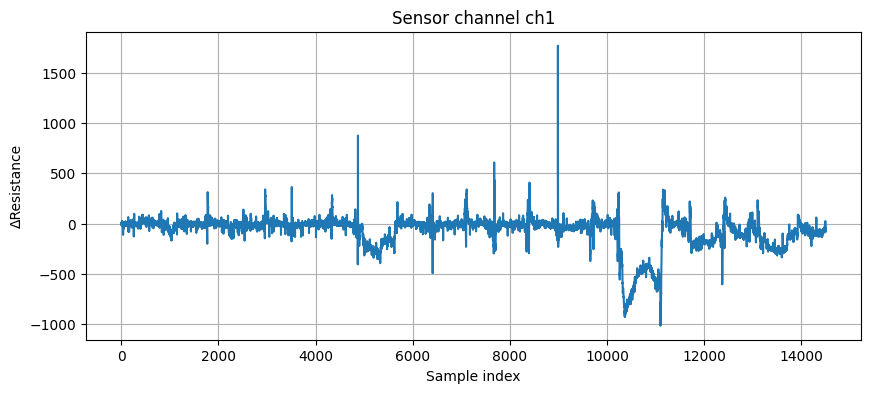

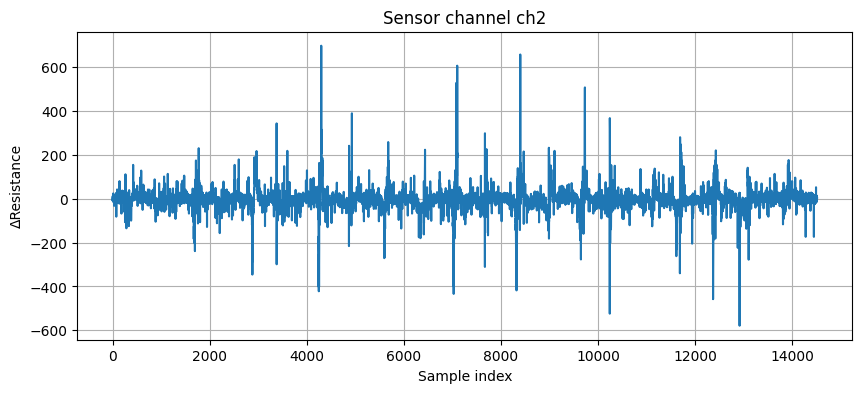

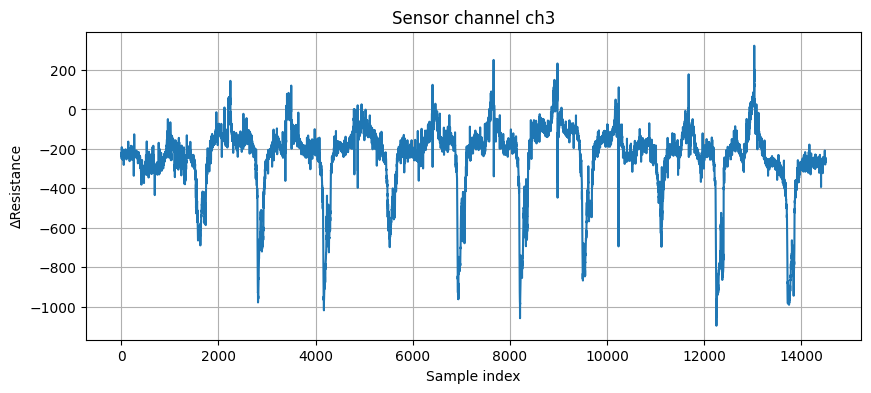

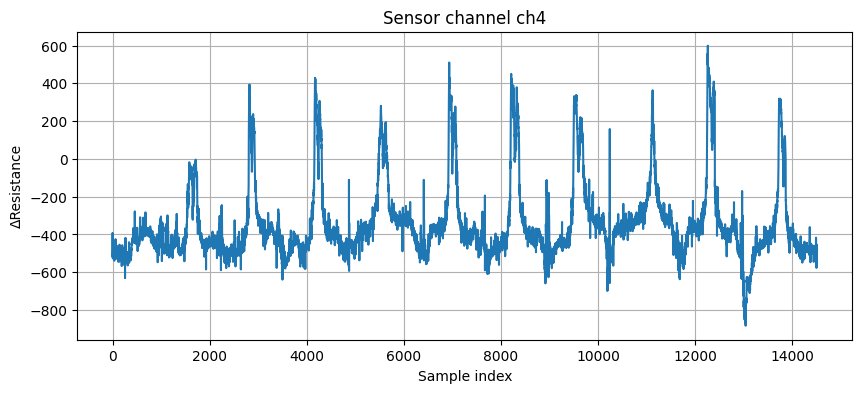

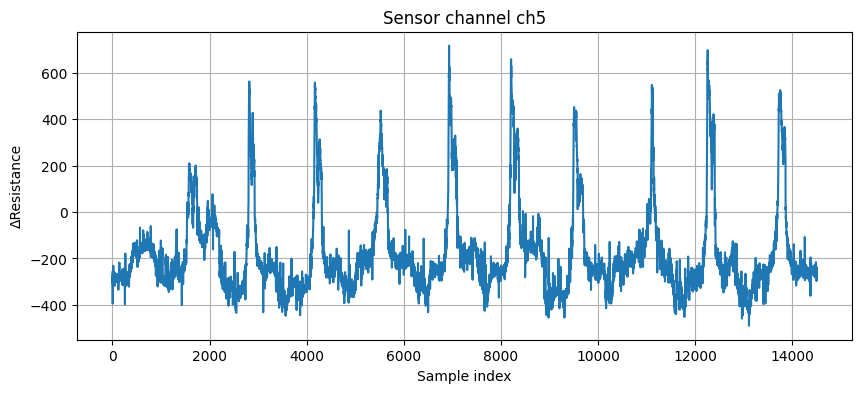

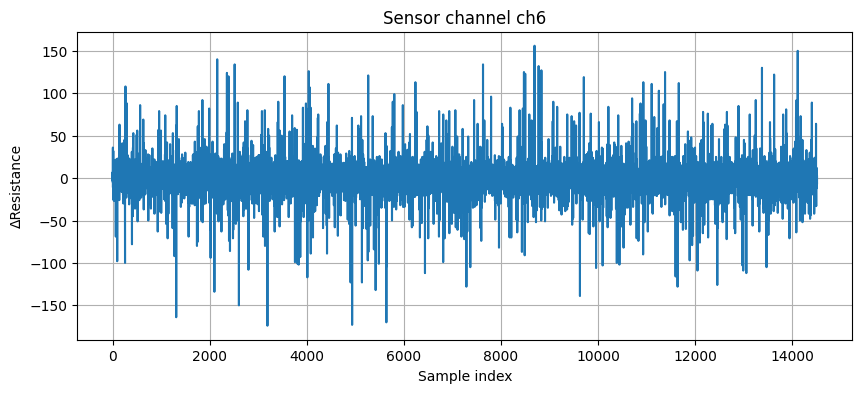

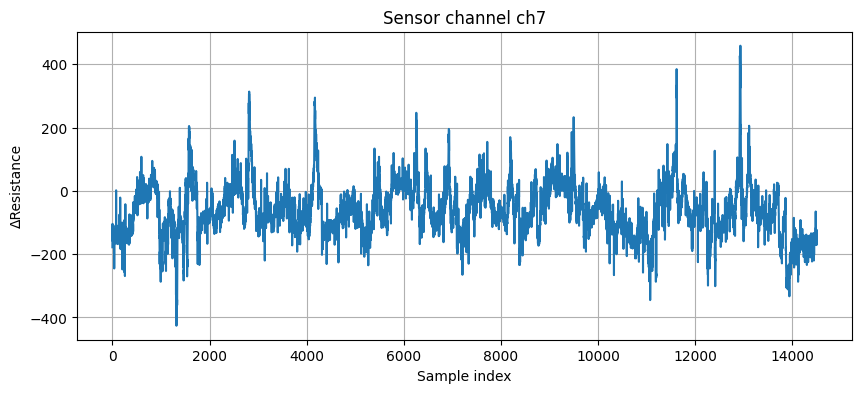

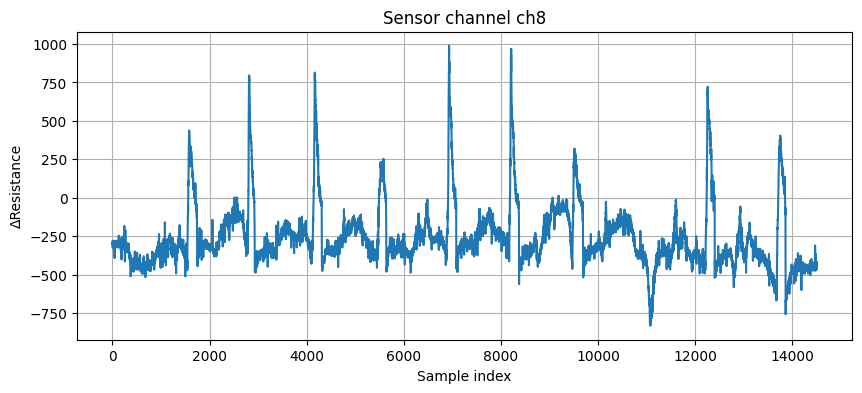

In [58]:
import matplotlib.pyplot as plt

channels = ["ch1","ch2","ch3","ch4","ch5","ch6","ch7","ch8"]

for ch in channels:
    plt.figure(figsize=(10,4))
    plt.plot(df1[ch])  # по оси X автоматически индекс 0..N-1
    plt.title(f"Sensor channel {ch}")
    plt.xlabel("Sample index")
    plt.ylabel("ΔResistance")
    plt.grid(True)
    plt.show()


In [59]:
import numpy as np

In [60]:
X = np.array(df1['ch8'])

In [61]:
#df1.to_csv('matlab_test.csv', index=False)

In [62]:
from scipy.signal import butter, filtfilt

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs           # частота Найквиста
    normal_cutoff = cutoff / nyq

    # проектируем фильтр
    b, a = butter(order, normal_cutoff, btype='low', analog=False)

    # применяем фильтр без фазовых искажений
    filtered = filtfilt(b, a, data)
    return filtered

# пример использования
#filtered_signal = butter_lowpass_filter(X, cutoff=2, fs=500)
filtered_signal_all = []
col = ['ch1','ch2','ch3','ch4','ch5','ch6','ch7','ch8']
for i in col:
    filtered_signal = butter_lowpass_filter(np.array(df1[i]), cutoff=2.5, fs=500)
    filtered_signal_all.append(filtered_signal)

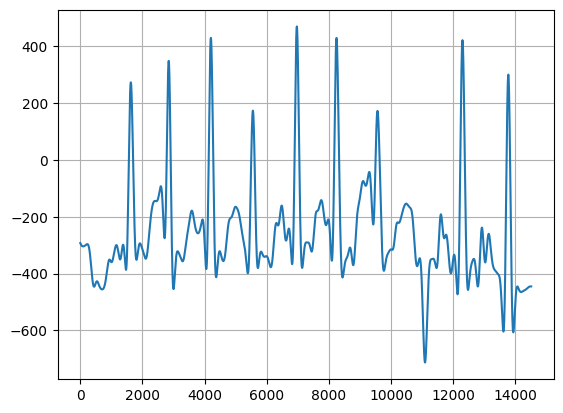

In [63]:
plt.plot(filtered_signal)
plt.grid()

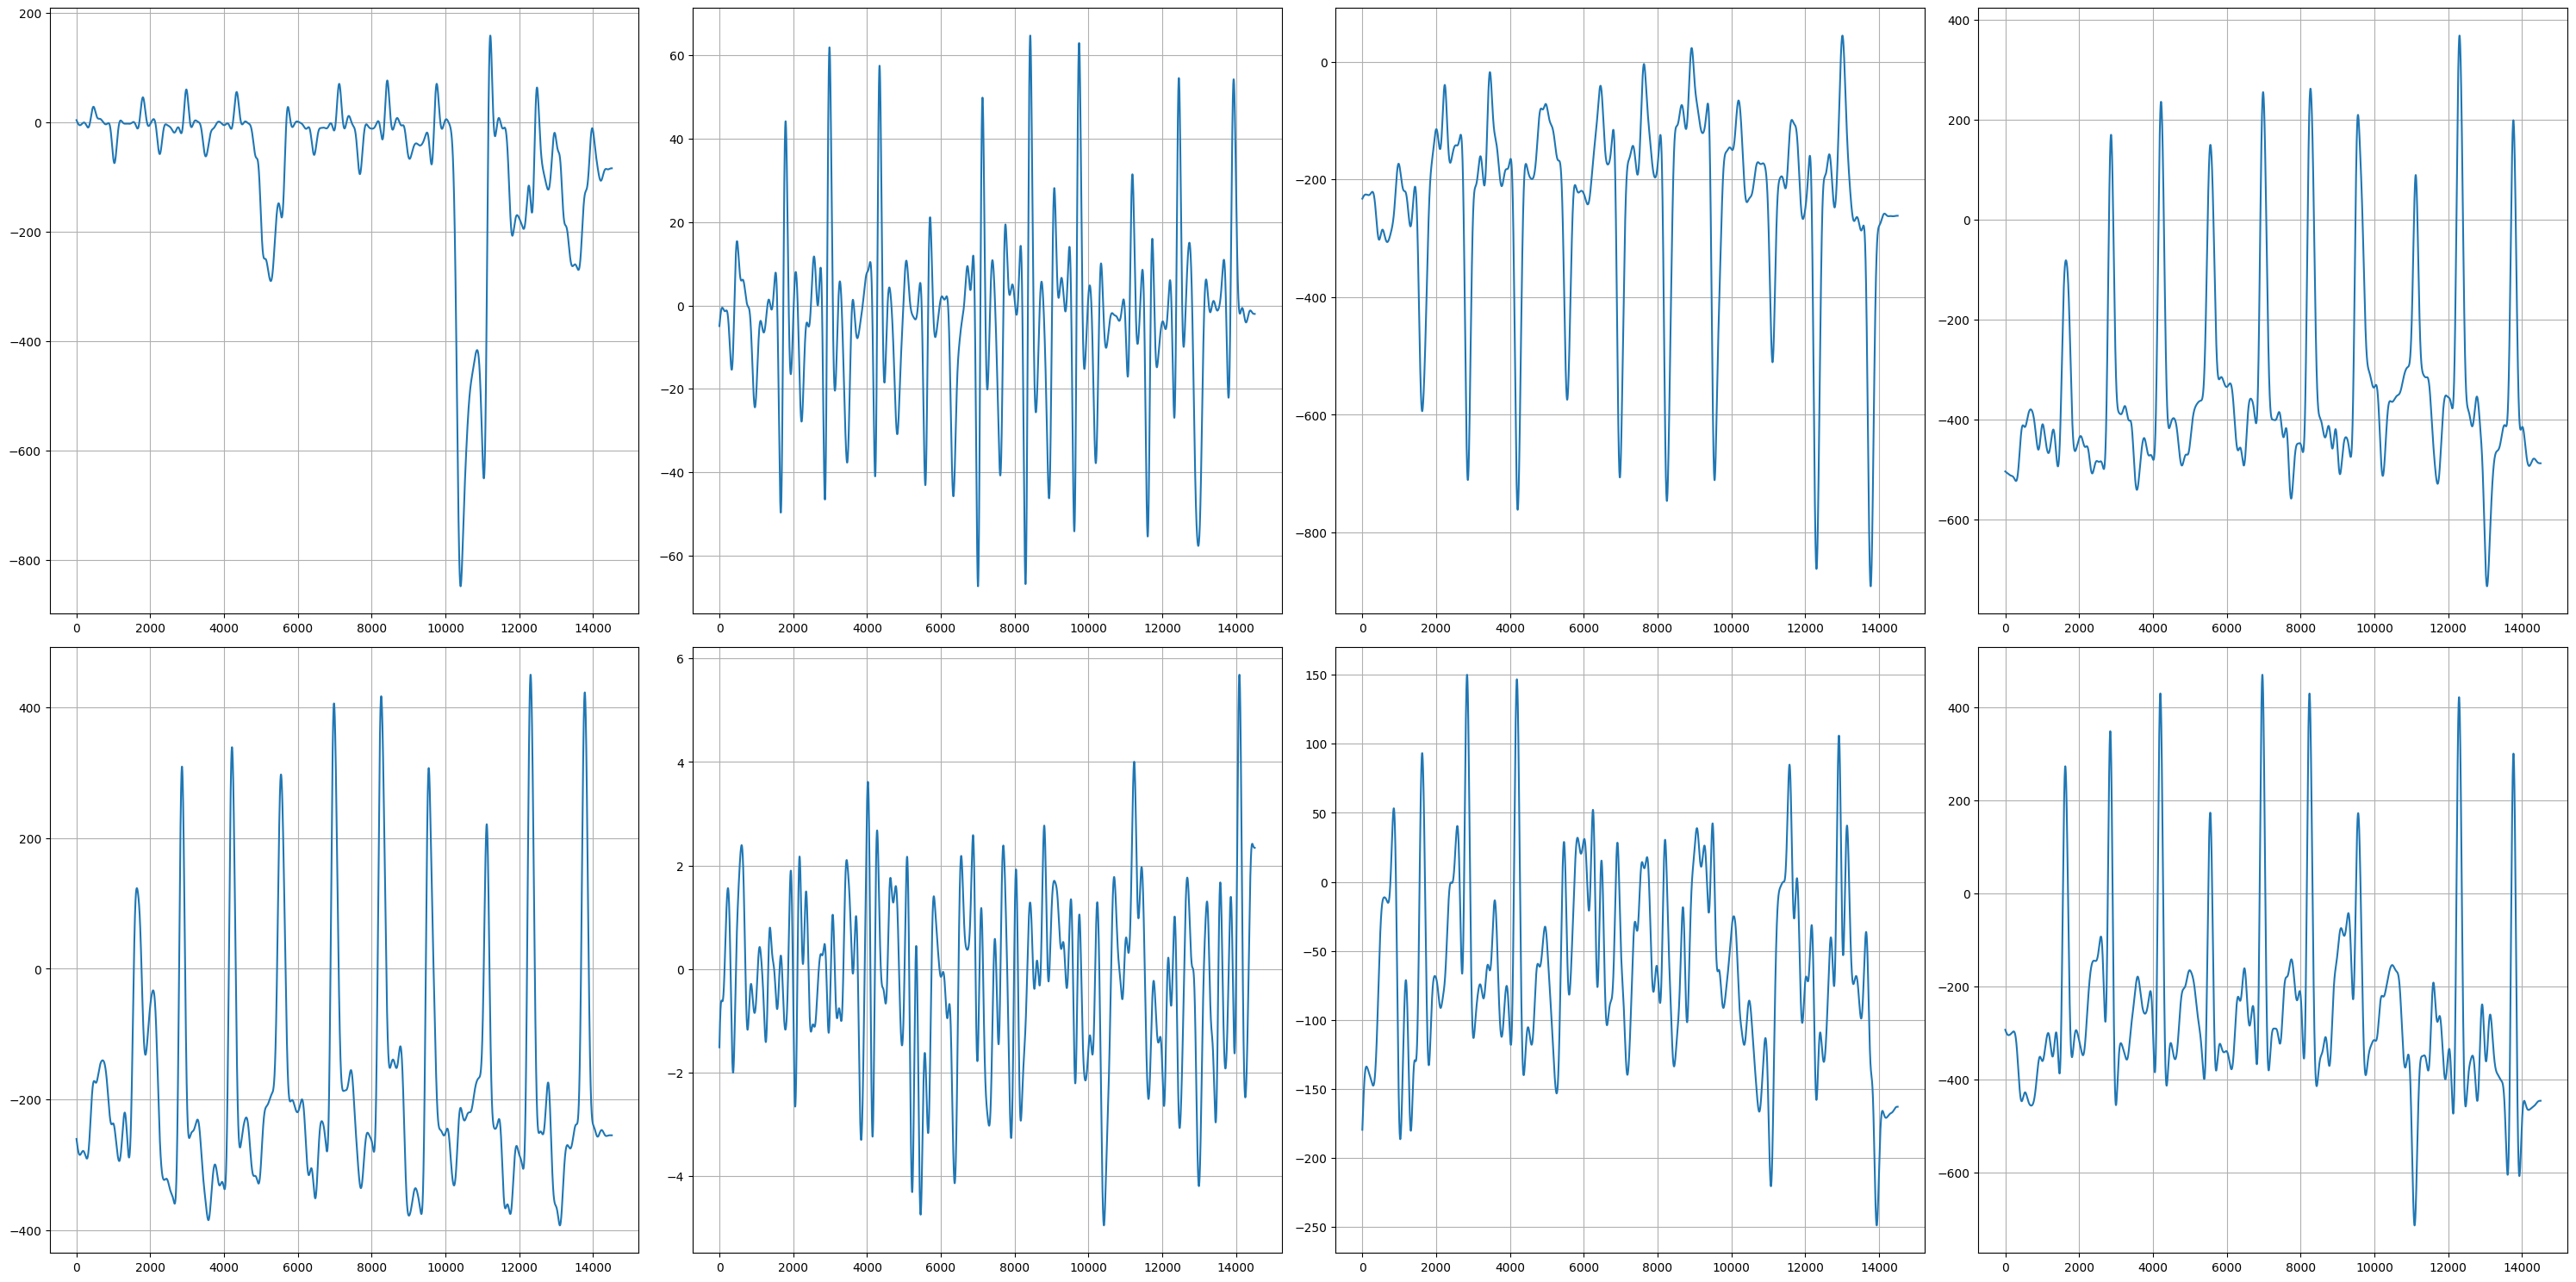

In [64]:
plt.figure(figsize=(30, 15))  # размер всей фигуры

for i, signal in enumerate(filtered_signal_all):    
    plt.subplot(2, 4, i+1)
    plt.plot(signal)
    plt.grid()

plt.tight_layout()
plt.show()

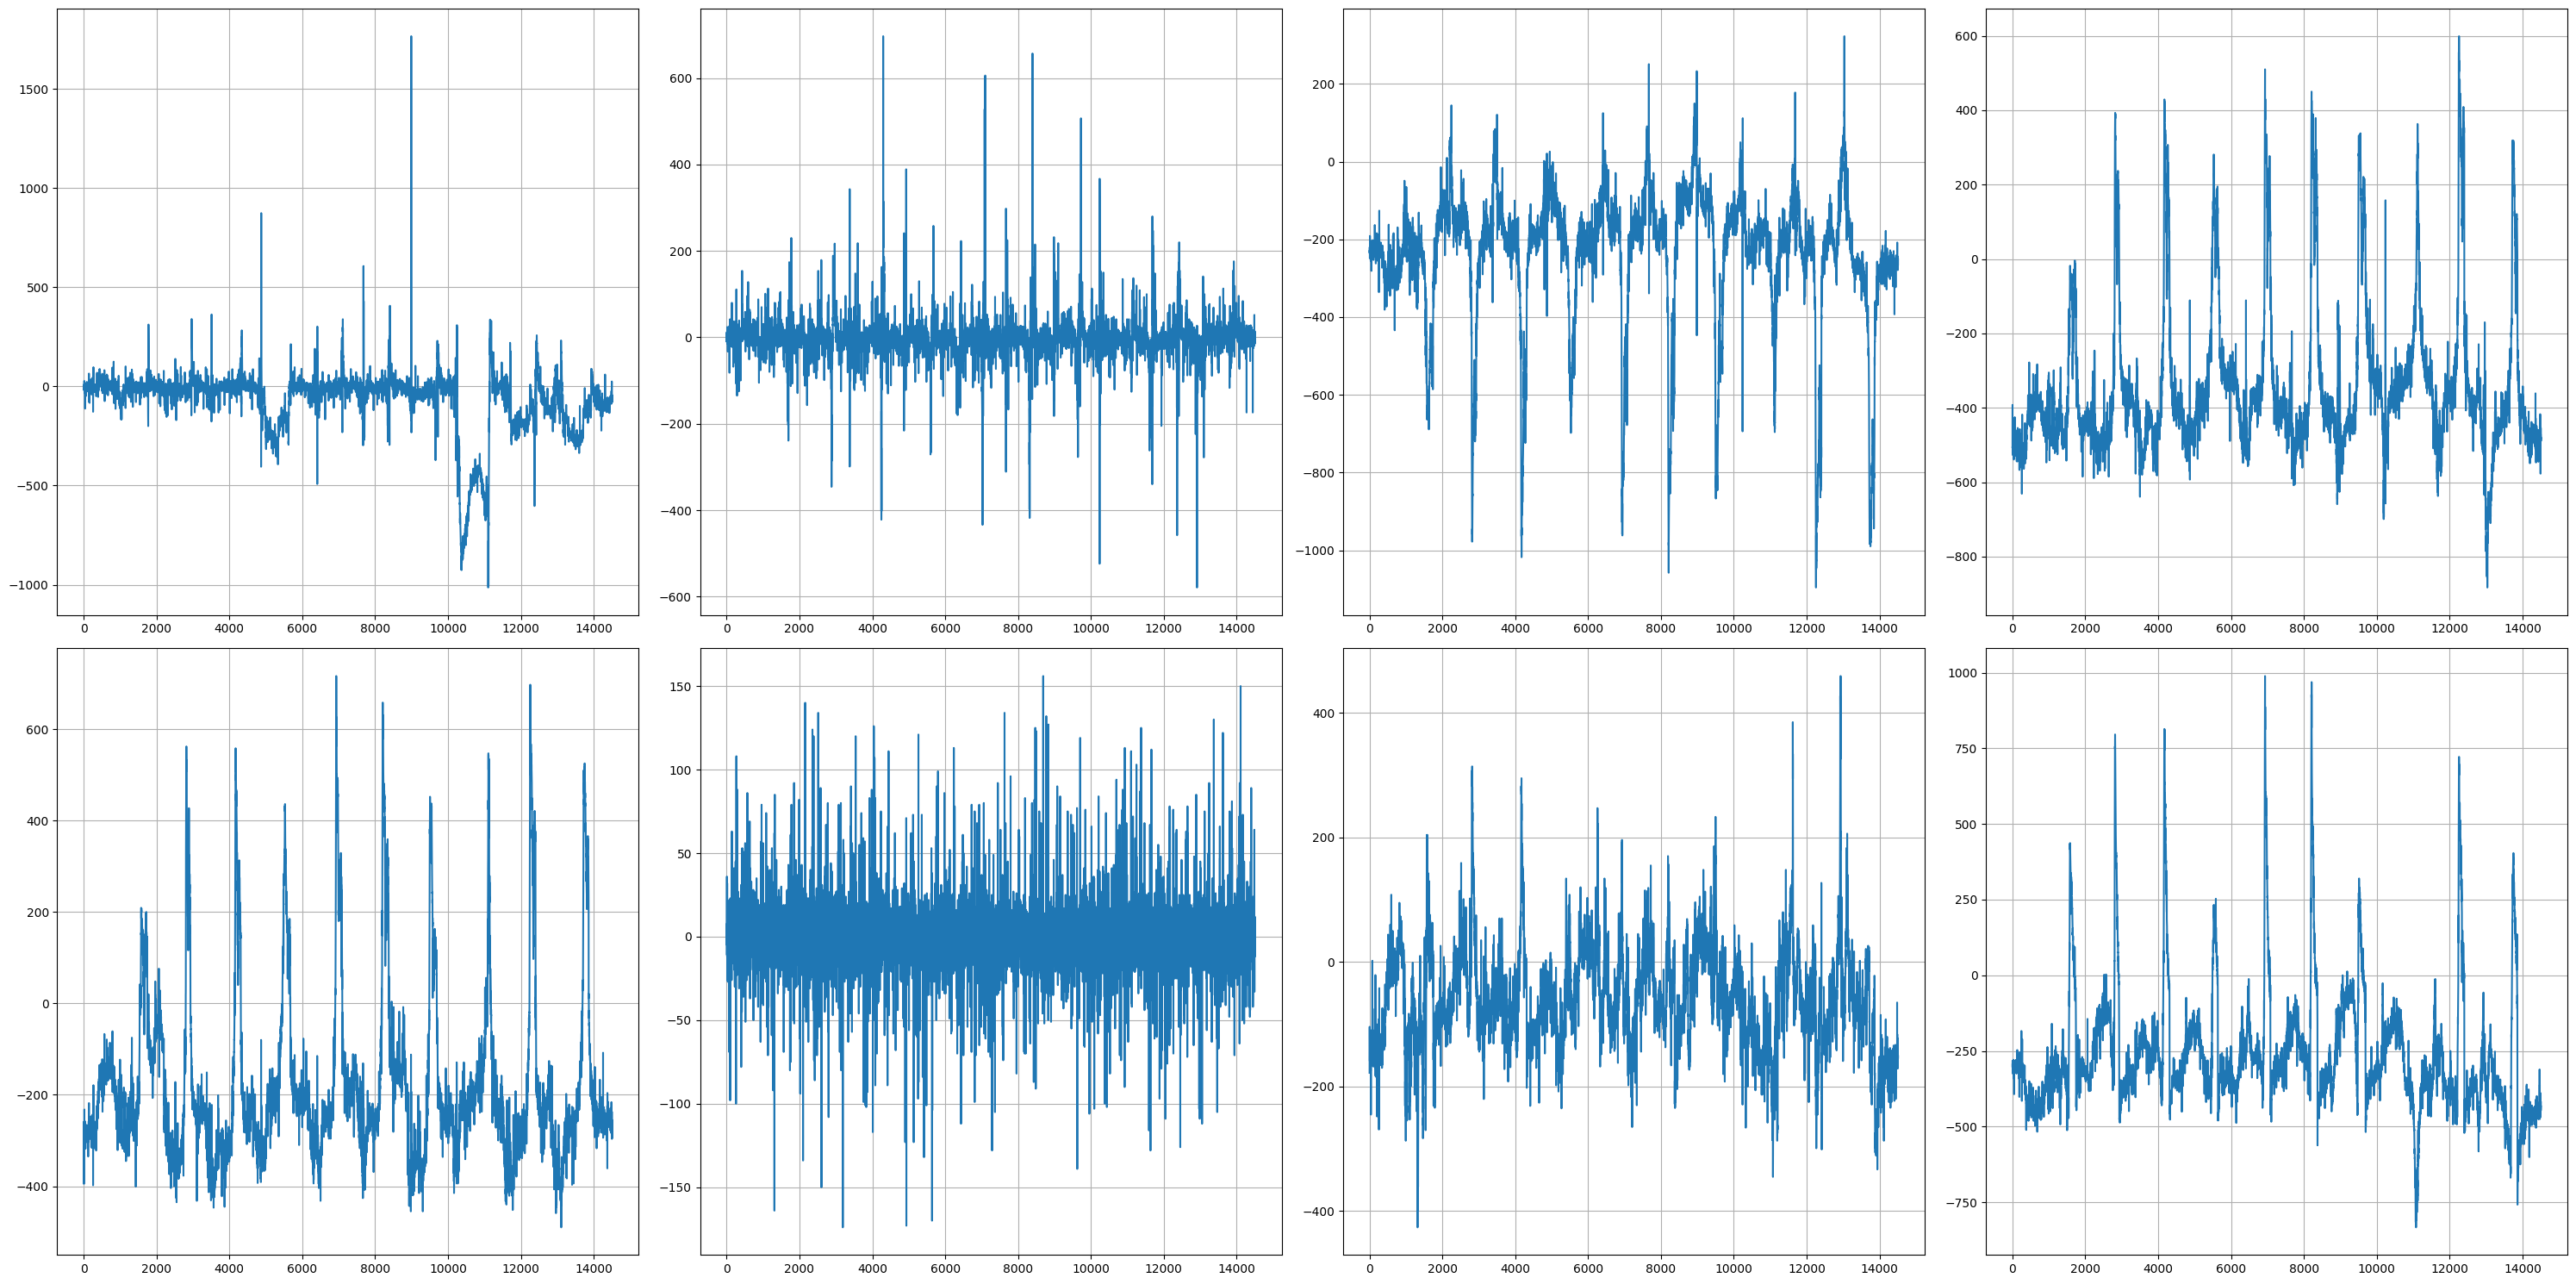

In [65]:
plt.figure(figsize=(30, 15))  # размер всей фигуры

for i, signal in enumerate(filtered_signal_all):    
    plt.subplot(2, 4, i+1)
    plt.plot(np.array(df1.iloc[:,i+1]))
    plt.grid()

plt.tight_layout()
plt.show()

In [66]:
from scipy.signal import decimate

fs_old = 500
fs_new = 10
decim_factor = int(round(fs_old / fs_new))  # ≈31

#X_down = decimate(X, decim_factor, axis=0, ftype='iir')
decim_signal_all = []
col = ['ch1','ch2','ch3','ch4','ch5','ch6','ch7','ch8']
for i in col:
    decim_signal = decimate(np.array(df1[i]), decim_factor, axis=0, ftype='fir')
    decim_signal_all.append(decim_signal)

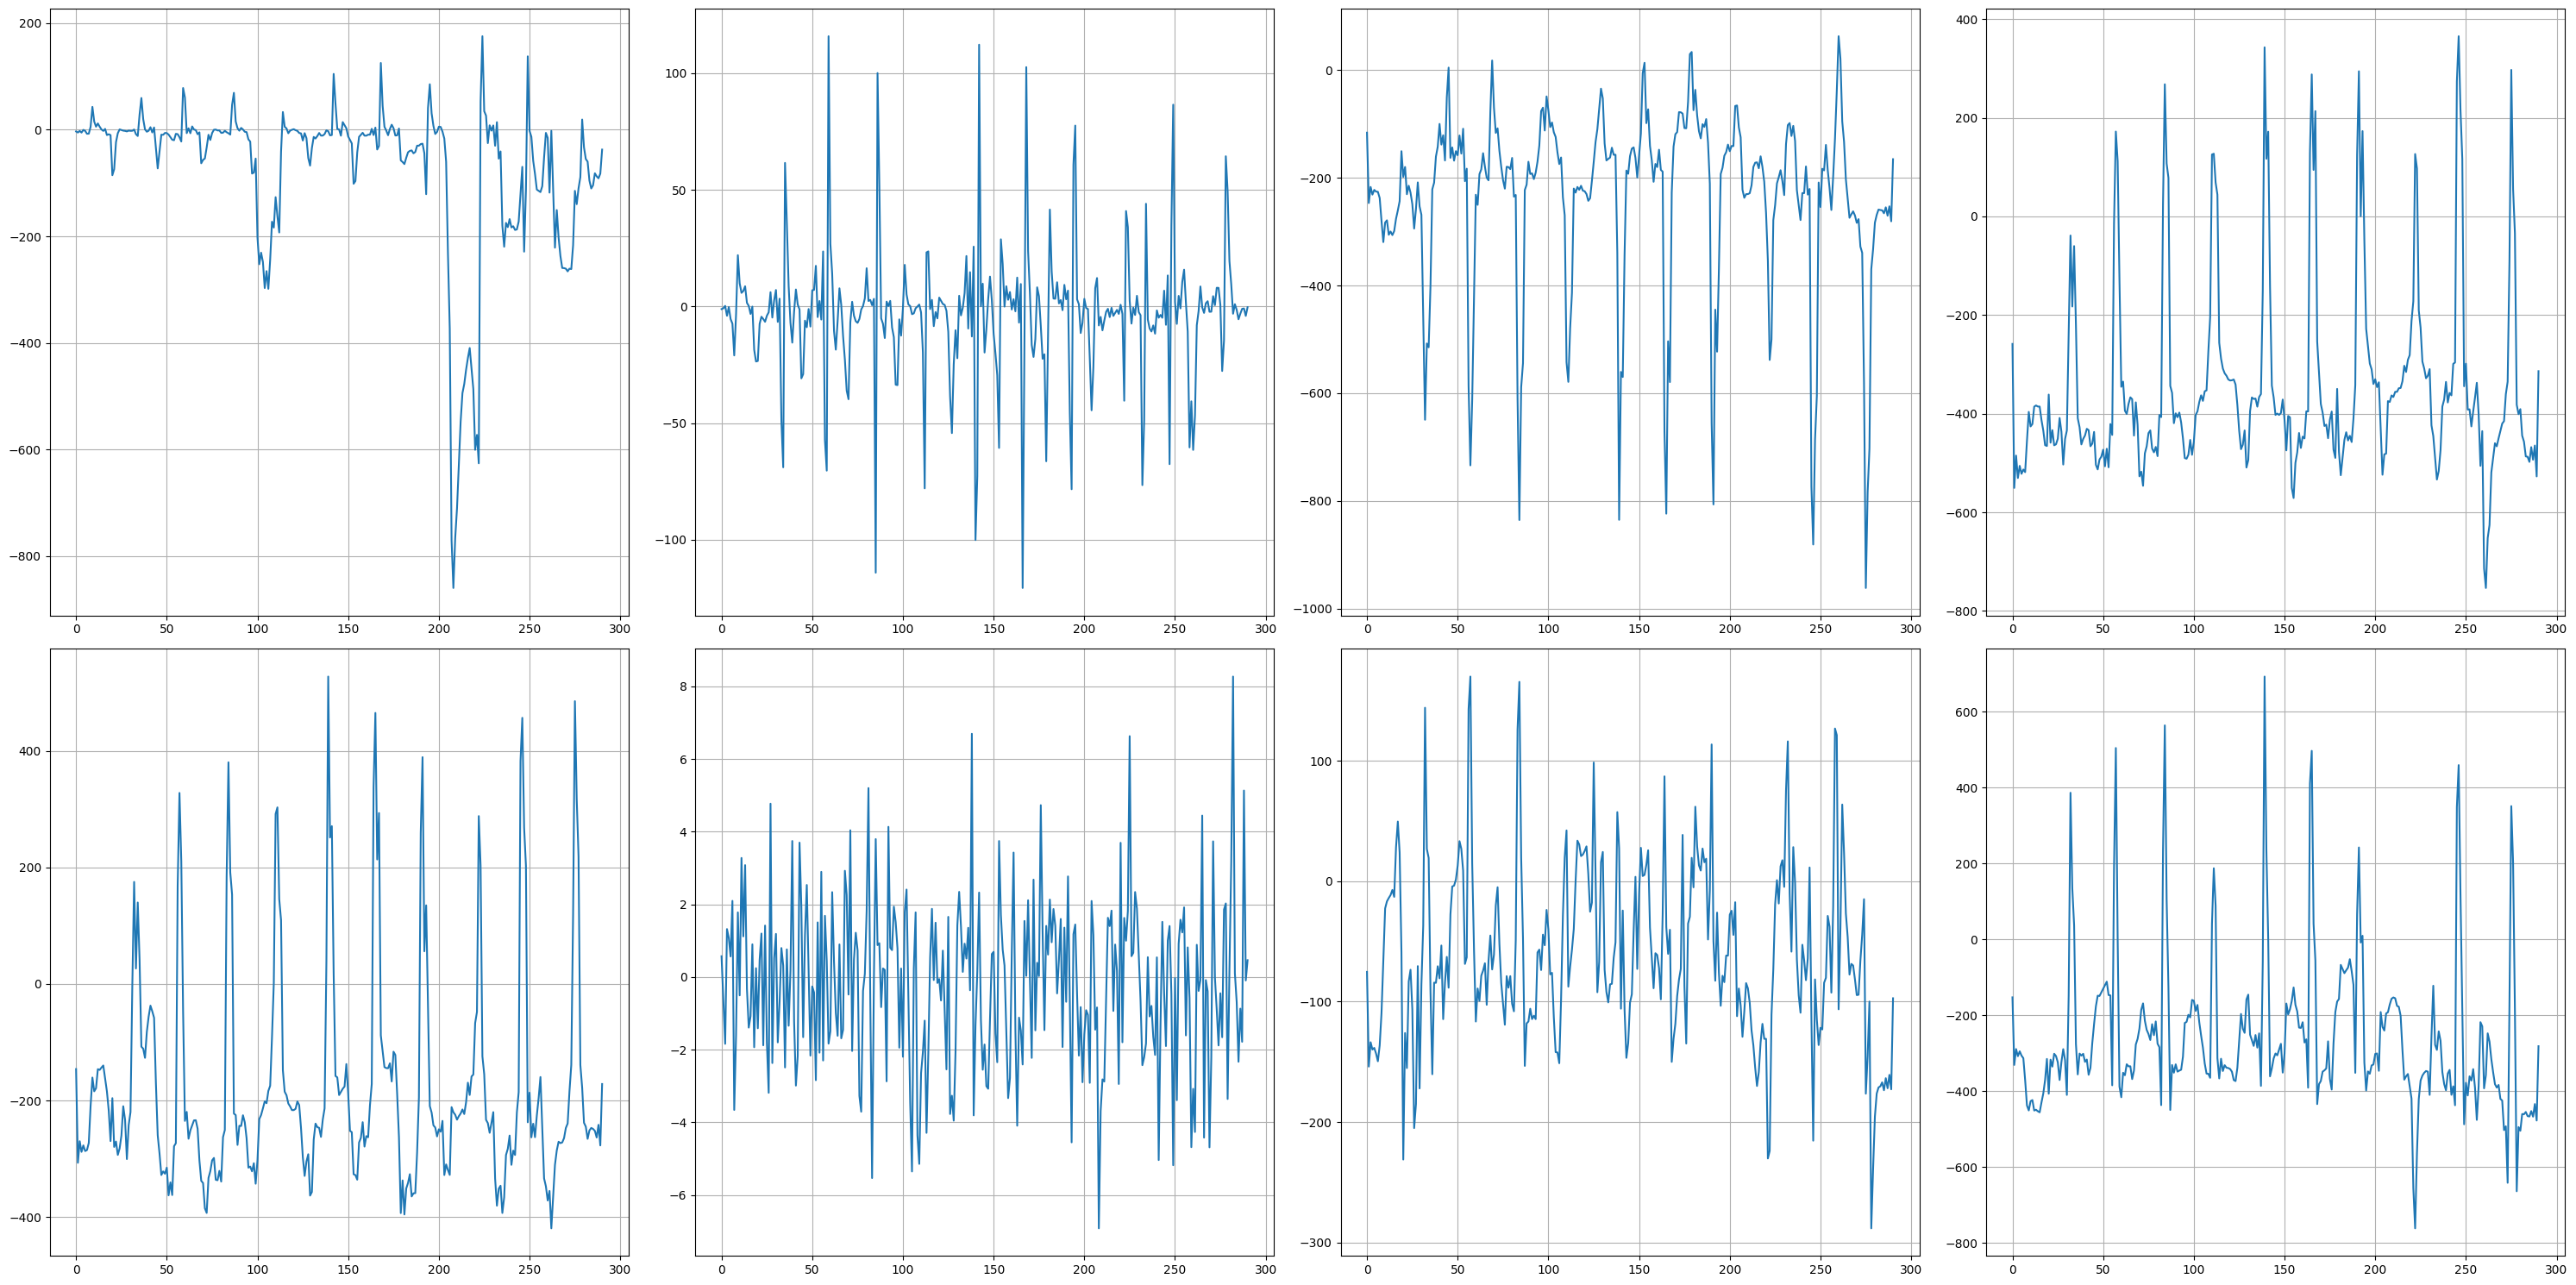

In [67]:
plt.figure(figsize=(30, 15))  # размер всей фигуры

for i, signal in enumerate(decim_signal_all):    
    plt.subplot(2, 4, i+1)
    plt.plot(signal)
    plt.grid()

plt.tight_layout()
plt.show()

In [68]:
from scipy.signal import decimate

fs_old = 500
fs_new = 20
decim_factor = int(round(fs_old / fs_new))  # ≈31

#X_down = decimate(X, decim_factor, axis=0, ftype='iir')
decim_signal_all_hand = []

for i in filtered_signal_all:
    decim_signal = i[::decim_factor]
    decim_signal_all_hand.append(decim_signal)

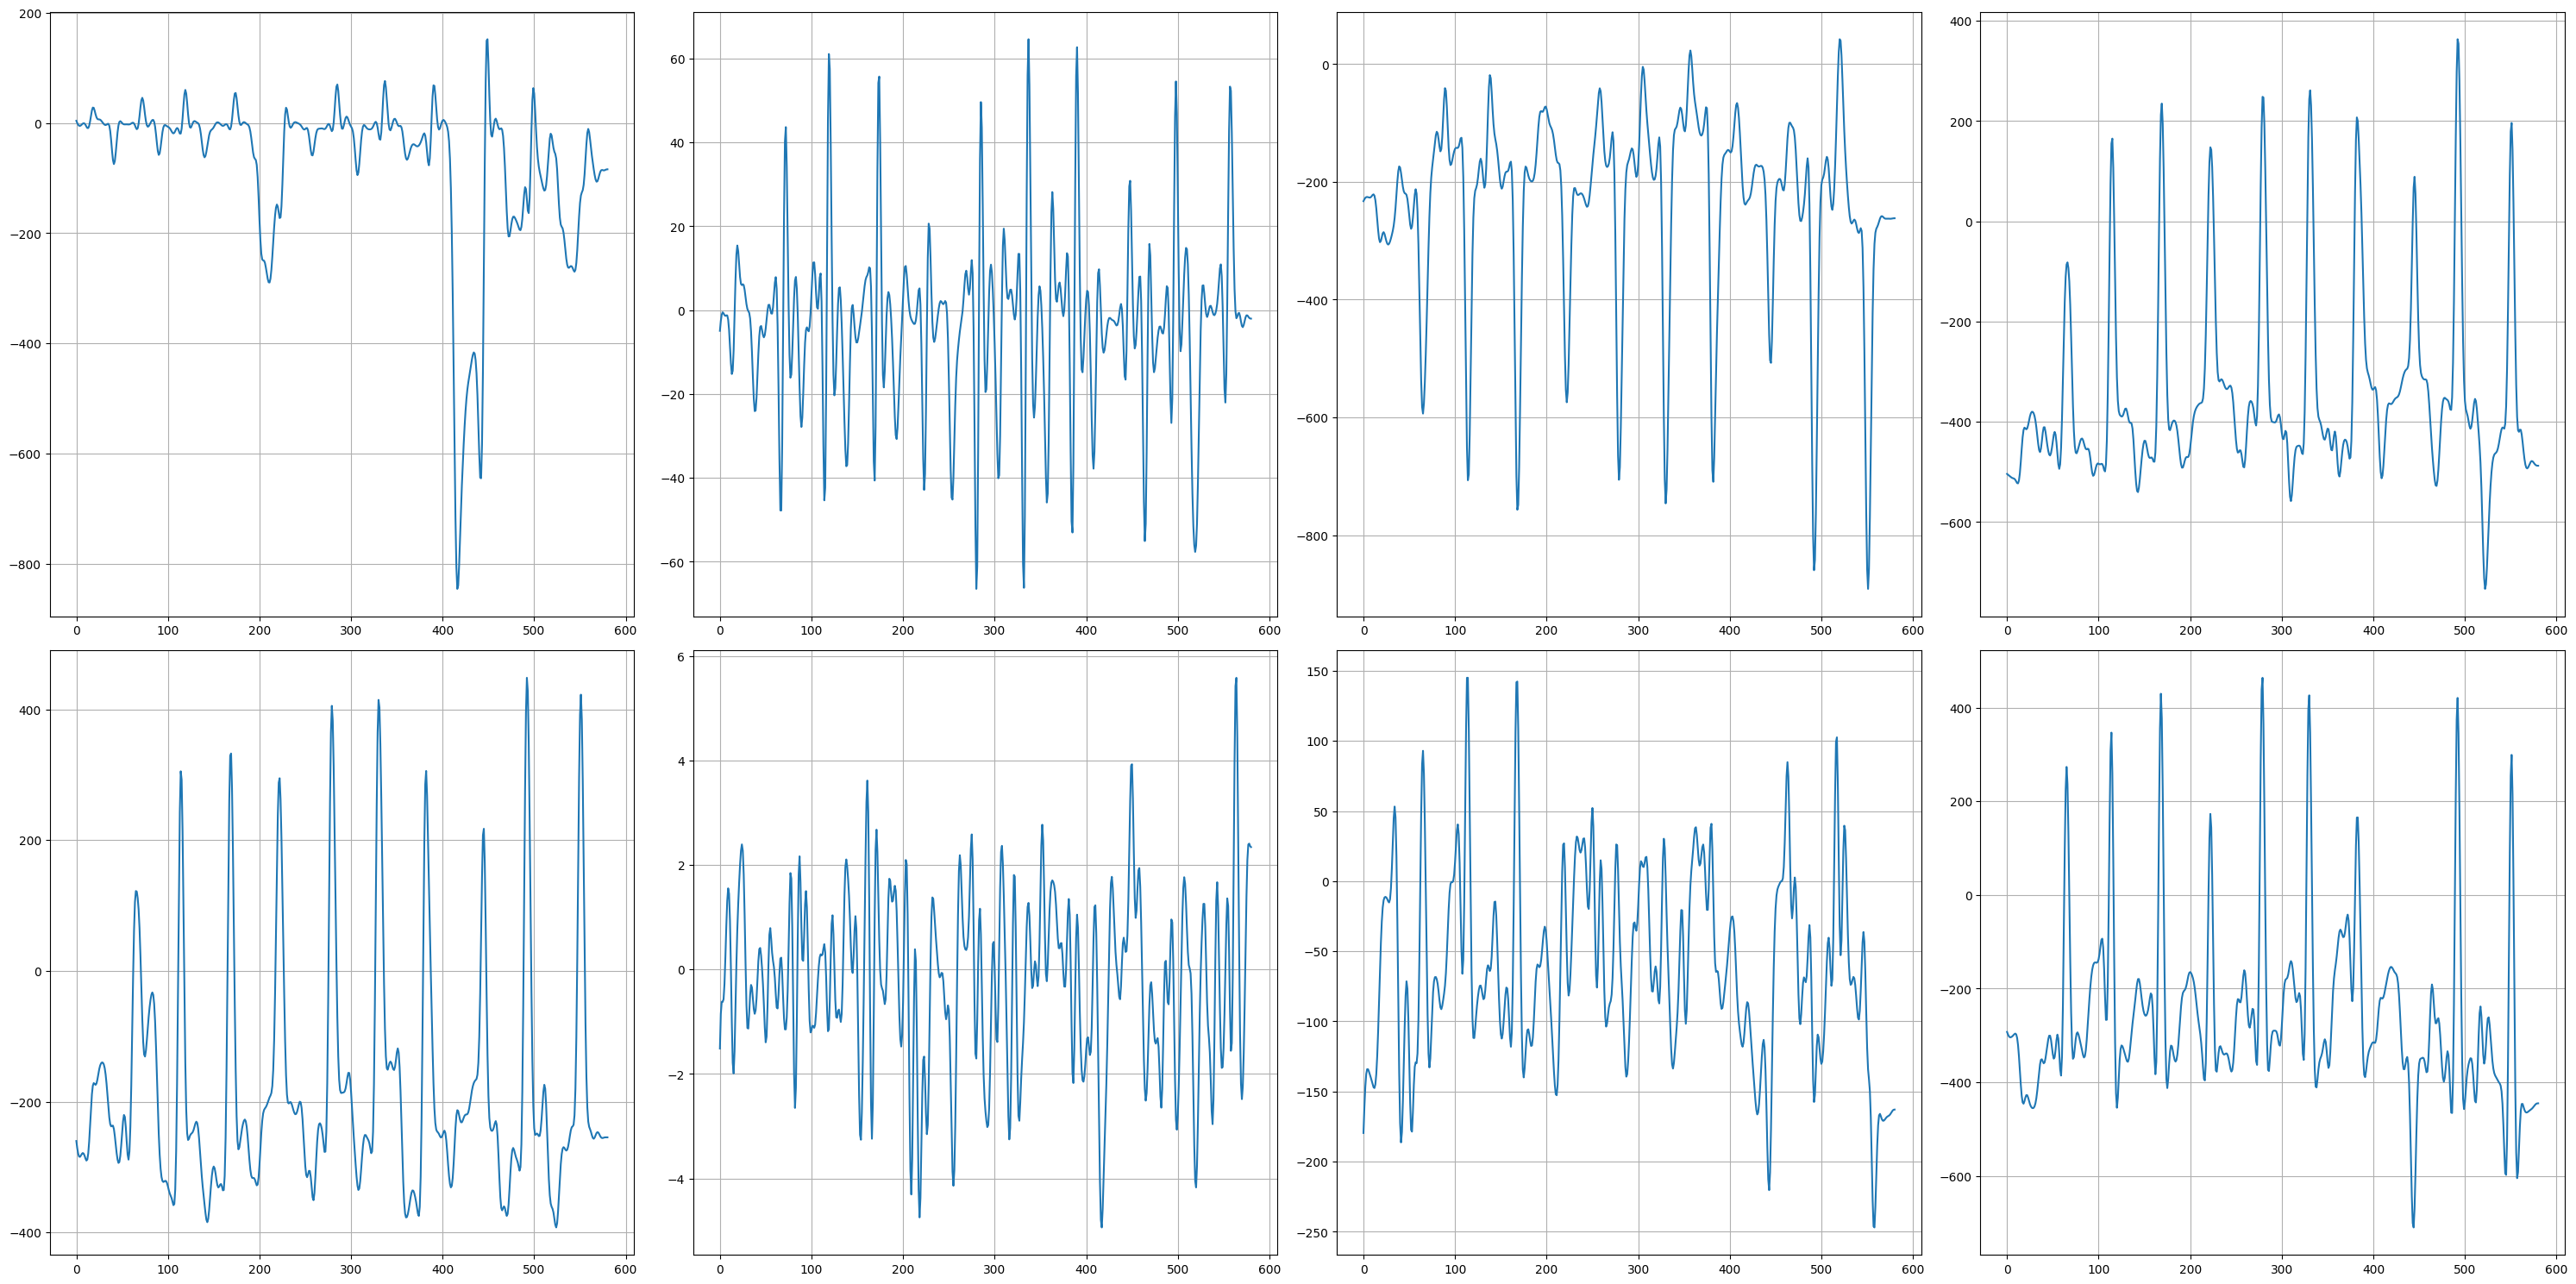

In [69]:
plt.figure(figsize=(30, 15))  # размер всей фигуры

for i, signal in enumerate(decim_signal_all_hand):    
    plt.subplot(2, 4, i+1)
    plt.plot(signal)
    plt.grid()

plt.tight_layout()
#plt.savefig("равновесия на двух.png", dpi=300)
plt.show()


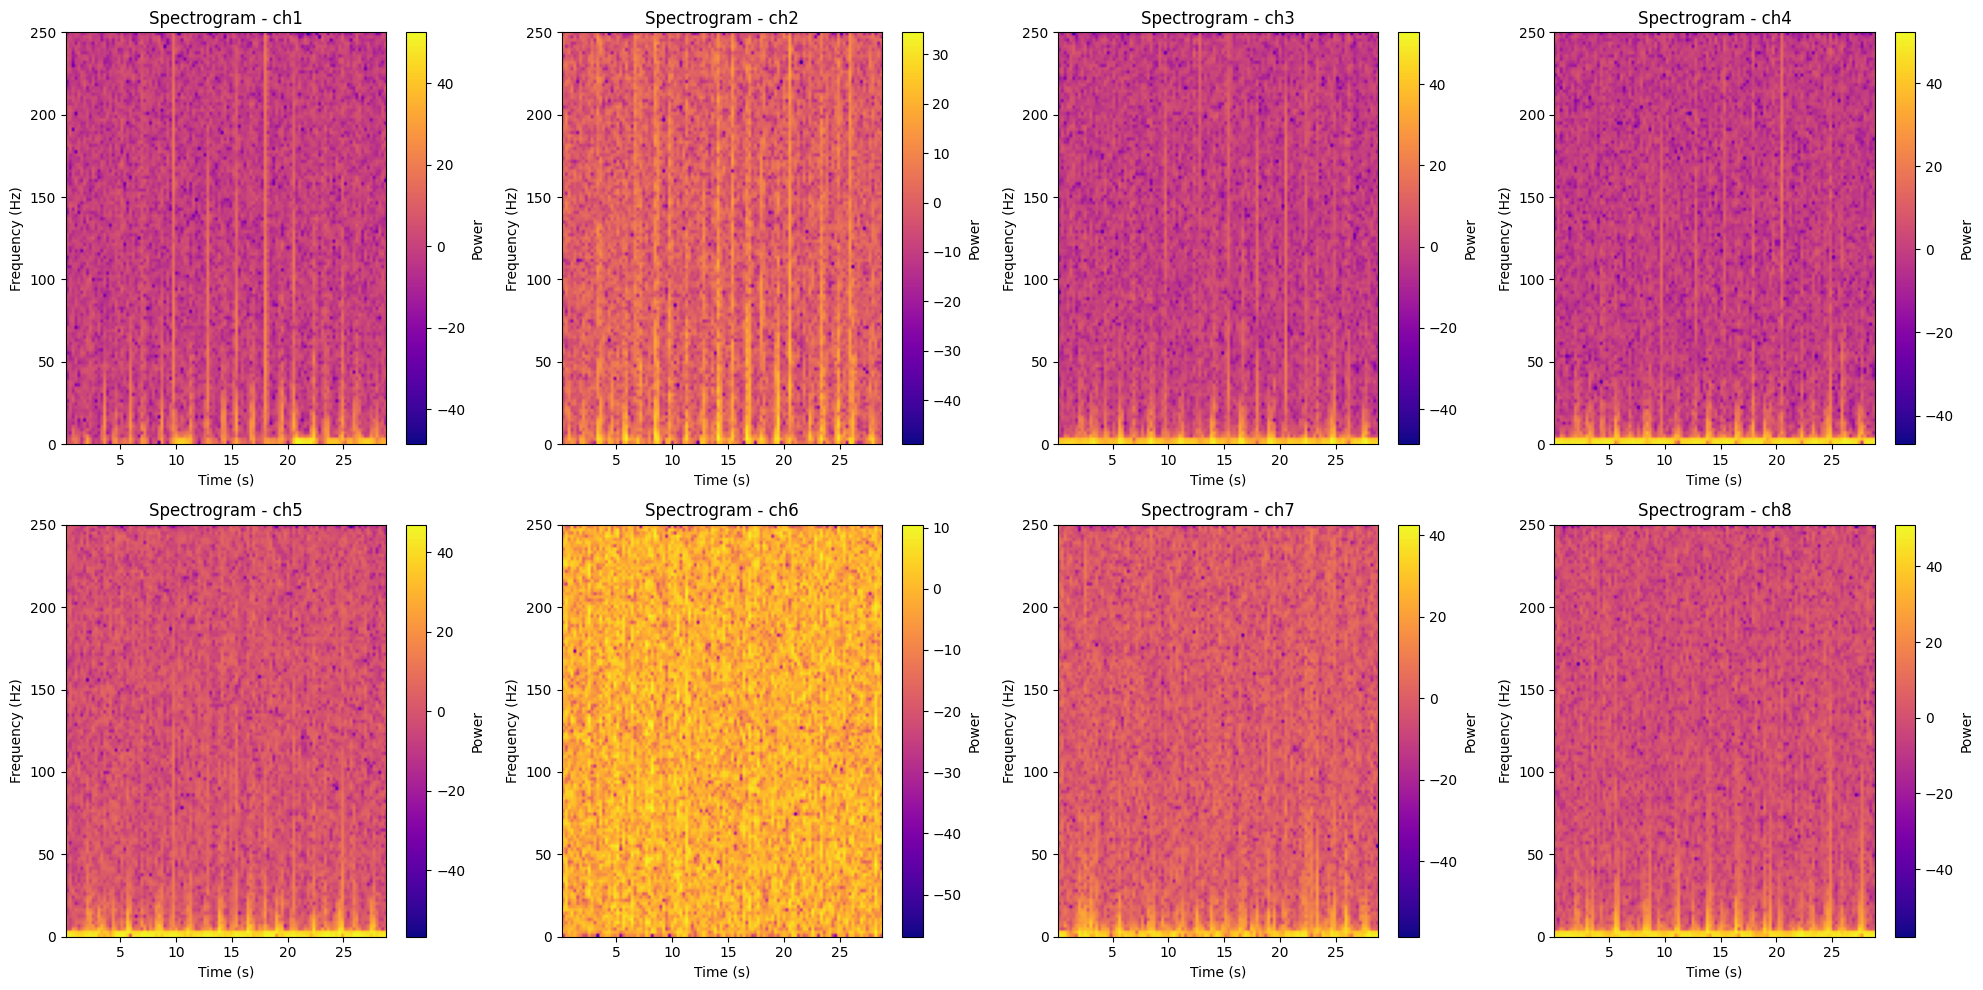

In [70]:
import matplotlib.pyplot as plt

fs = 500  # частота дискретизации

channels = [f'ch{i}' for i in range(1, 9)]  # ['ch1', 'ch2', ..., 'ch8']

plt.figure(figsize=(20, 10))  # размер всей фигуры

for i, ch in enumerate(channels, 1):
    signal = df1[ch].values
    plt.subplot(2, 4, i)
    plt.specgram(signal, NFFT=256, Fs=fs, noverlap=128, cmap='plasma')
    plt.title(f"Spectrogram - {ch}")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Power")  # отдельная цветовая шкала для каждого графика

plt.tight_layout()
plt.show()


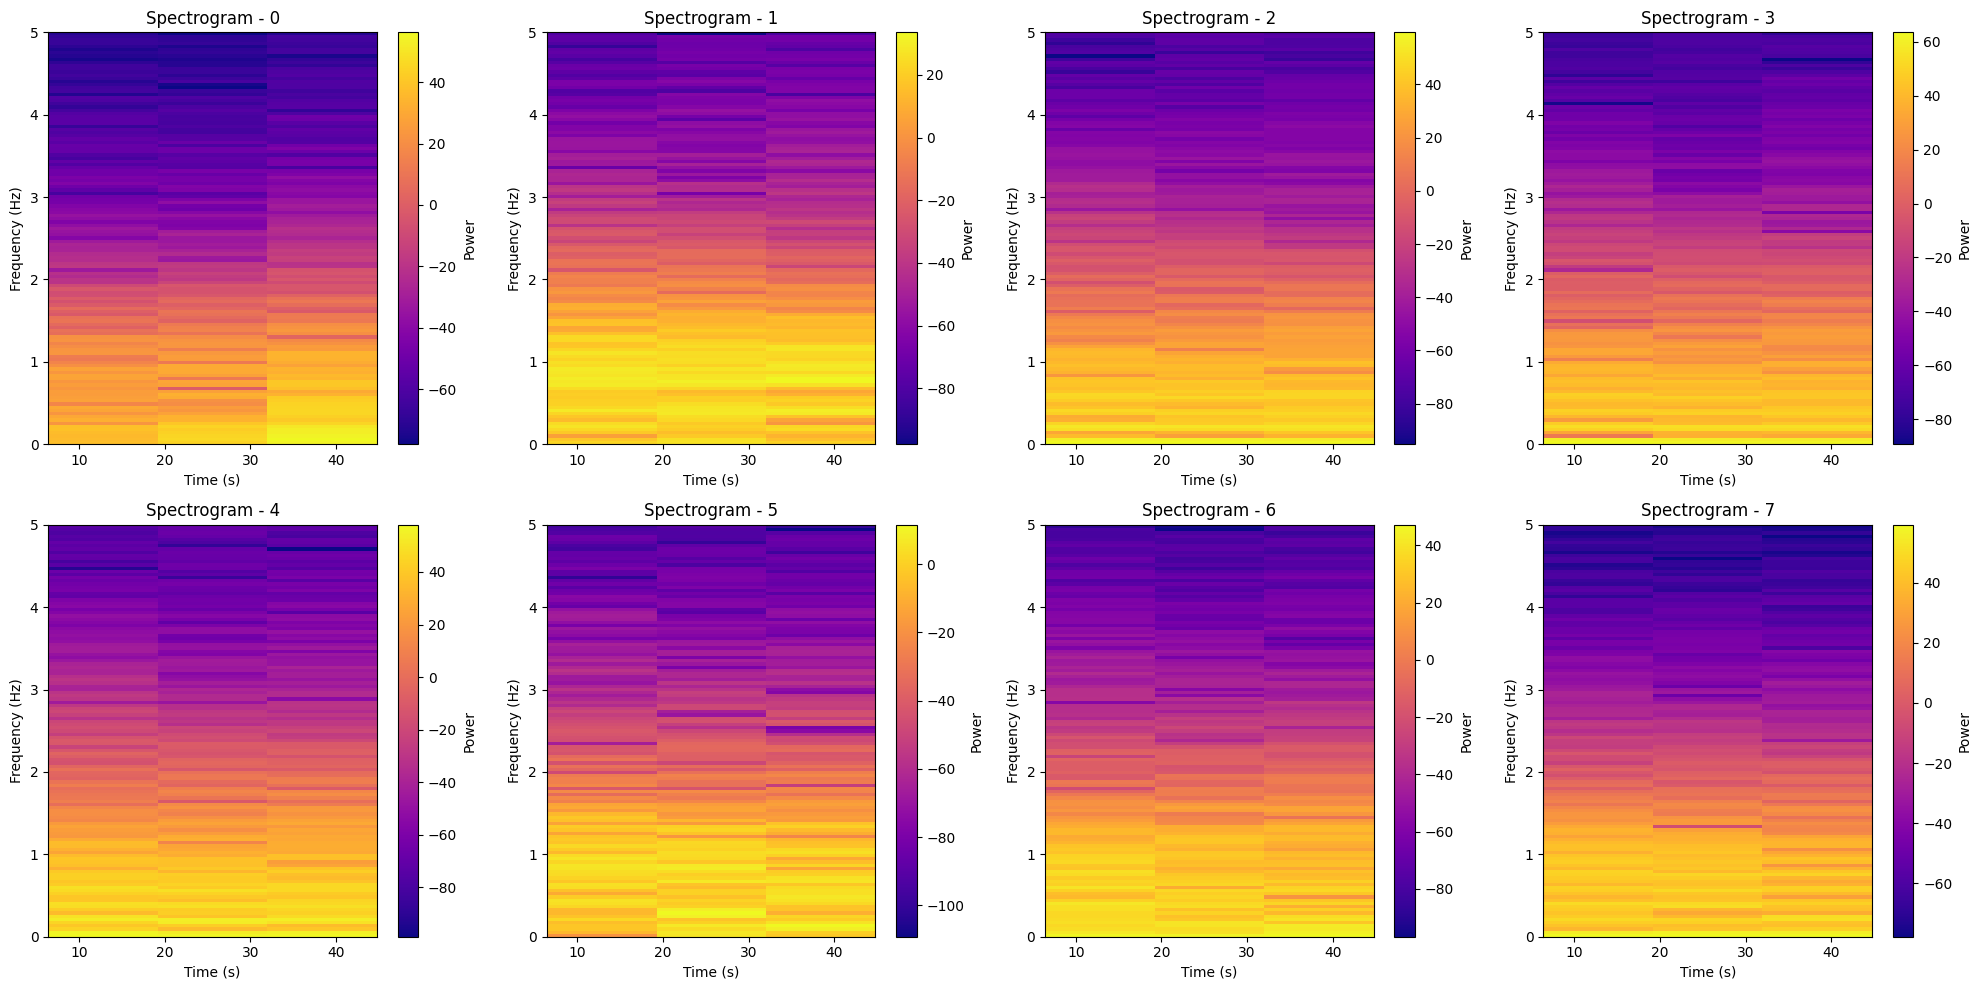

In [71]:
fs = 10 


plt.figure(figsize=(20, 10))  # размер всей фигуры

#plt.figure(figsize=(30, 15))  # размер всей фигуры

for i, signal in enumerate(decim_signal_all_hand):    
    plt.subplot(2, 4, i+1)
    plt.specgram(signal, NFFT=256, Fs=fs, noverlap=128, cmap='plasma')
    plt.title(f"Spectrogram - {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Power")  # отдельная цветовая шкала для каждого графика

plt.tight_layout()
plt.show()

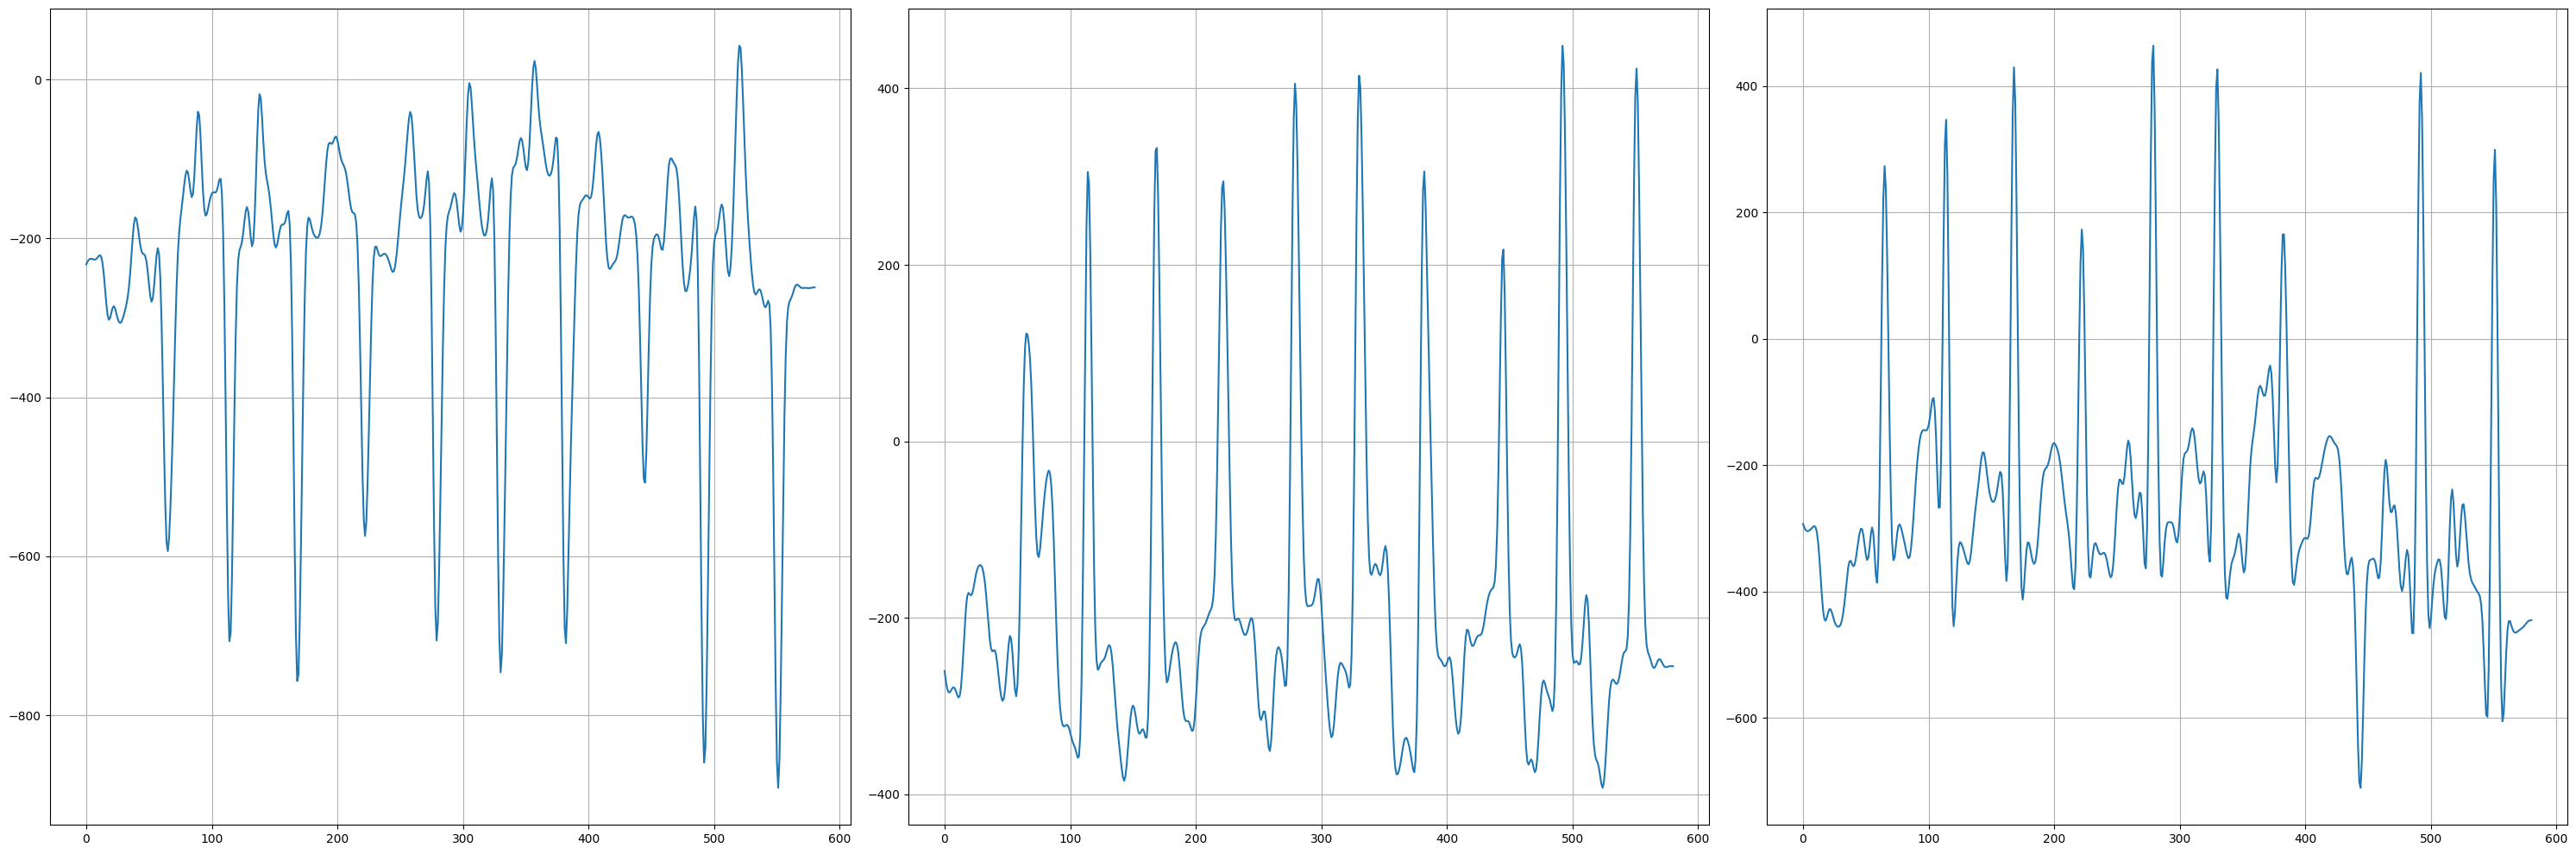

In [72]:
plt.figure(figsize=(30, 10))  # размер всей фигуры

plt.subplot(1, 3, 1)
plt.plot(decim_signal_all_hand[2])
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(decim_signal_all_hand[4])
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(decim_signal_all_hand[7])
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()


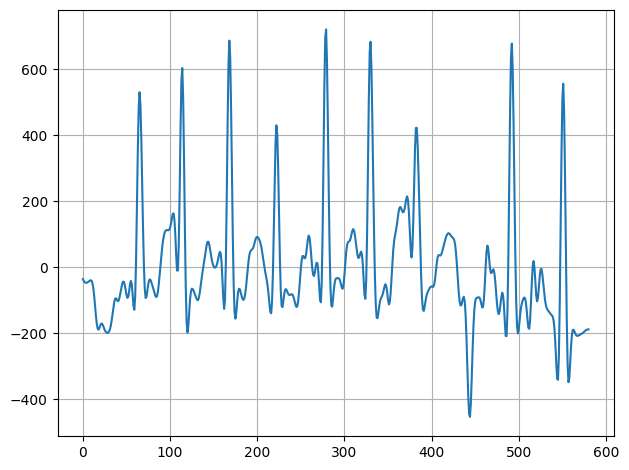

In [73]:
signal = decim_signal_all_hand[7]

detail = signal - np.mean(signal)

plt.plot((detail))
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()

In [74]:
def autocorr(x):
    x = np.asarray(x)
    x = x - x.mean()
    result = np.correlate(x, x, mode='full')
    return result[result.size//2:] / result[result.size//2]

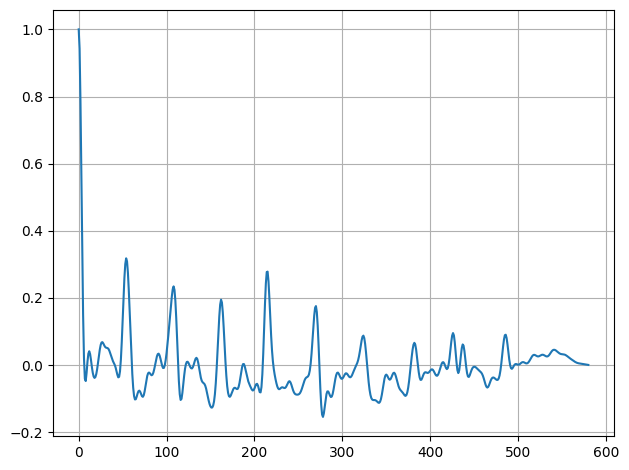

In [75]:
detail = autocorr(detail)

plt.plot((detail))
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()

In [76]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w)/w, mode='same')

In [86]:
detail = decim_signal_all_hand[7]

In [87]:
dy = np.gradient((detail))

In [88]:
dyX = np.where(dy < 0, 0, dy)

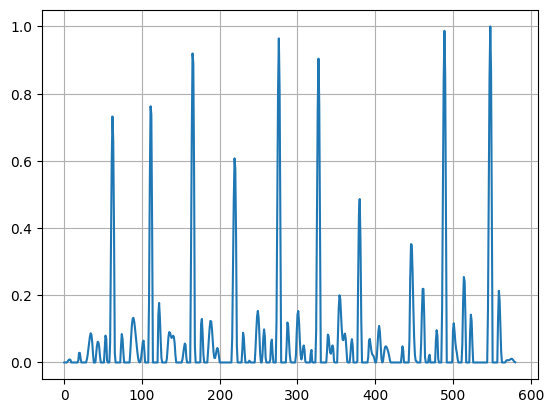

In [89]:
#signal_check = moving_average(abs(dyX),4)
signal_check = dyX
signal_check = (signal_check/np.max(signal_check)) #
plt.plot(signal_check)
#plt.plot(dyX)
plt.grid()
plt.show()

In [81]:
np.mean(signal_check)

0.07442763082390844

In [84]:
#signal_check2 = autocorr(signal_check)

In [102]:
signal_check2 = signal_check**2
signal_check2 = 10*signal_check2
#signal_check2 = signal_check * np.exp(*signal_check**2) ####1.5
signal_check2 = np.where(signal_check2>1, 1, signal_check2)

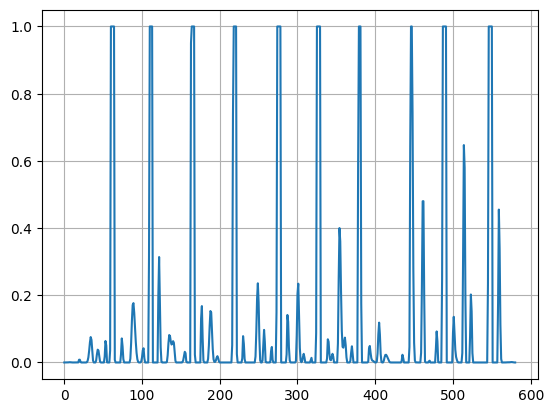

In [103]:
plt.plot(signal_check2)
#plt.plot(dyX)
plt.grid()
plt.show()

In [610]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(signal_check2, distance=5,height=0.95)

In [611]:
peaks

array([109, 220, 293, 361, 427, 486, 552], dtype=int64)

In [612]:
peaks.shape

(7,)

In [508]:
np.sum(signal_check>np.mean(signal_check)*3.5)

45

In [140]:
np.mean(signal_check)

6.6300069314396595

In [20]:
decim_signal_all_hand[2][46]

-313.8640681382231

In [21]:
decim_signal_all_hand[4][46]

-187.845250834658

In [22]:
decim_signal_all_hand[7][46]

-140.3418224269512

In [23]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w)/w, mode='same')

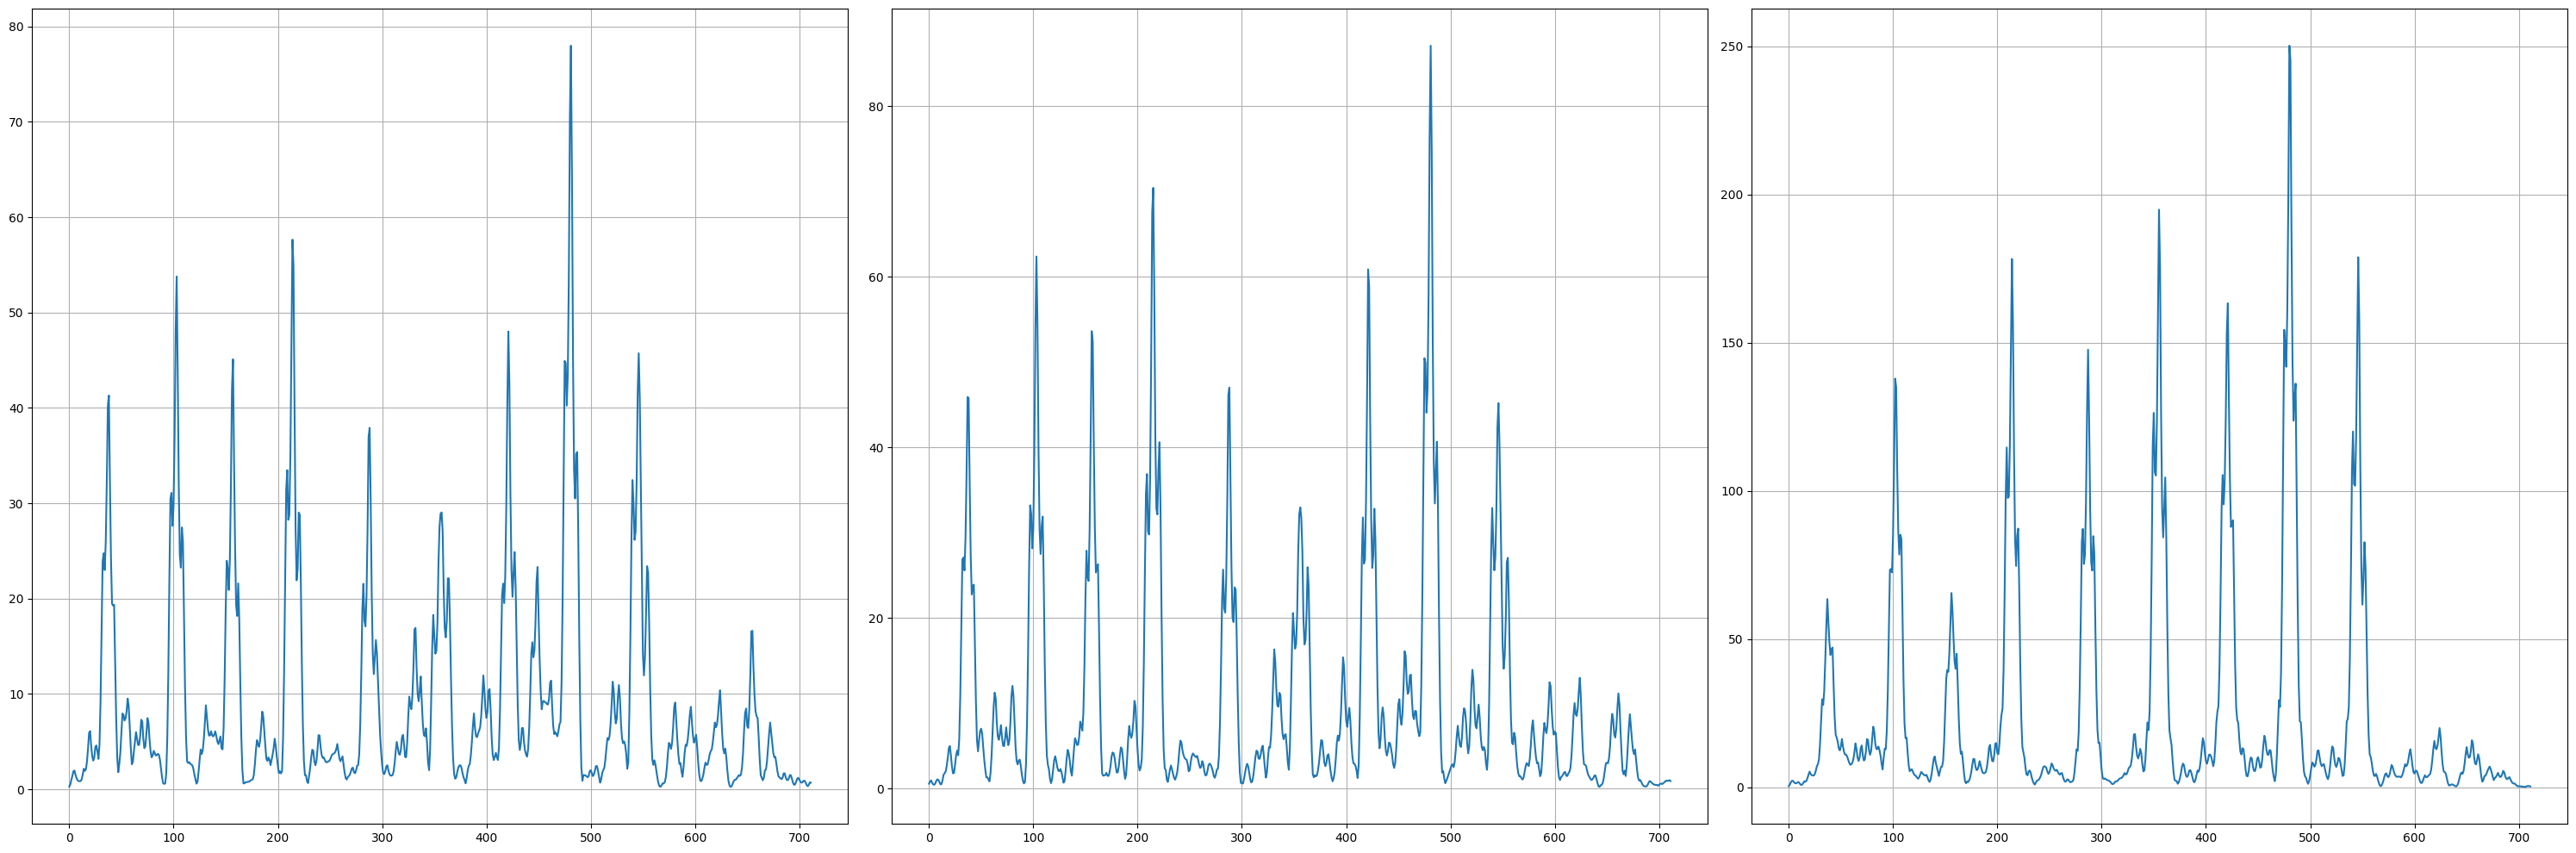

In [32]:
import numpy as np
import pywt
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def find_peaks_signal(signal):
    #signal = decim_signal_all_hand[7]

    # ----- 1. Вейвлет-преобразование -----
    # Daubechies 4: хорошо выделяет резкие обрывы
    wavelet = 'mexh'  # Continuous wavelet

    scales = np.arange(1, 10)

    # CWT возвращает матрицу: scale × time
    coeffs, freqs = pywt.cwt(signal, scales, wavelet)

    # Обычно выбирают один «оптимальный» масштаб: например scale=15
    cwt_level = coeffs[0]
    return cwt_level

    #peaks, _ = find_peaks(cwt_level, height=110, distance=5)

# ----- 3. Визуализация -----
#plt.figure(figsize=(16,6))

#plt.subplot(2,1,1)
#plt.title("Сигнал")
#plt.plot(signal)
#plt.scatter(peaks, signal[peaks], color='red')
#plt.grid()

#plt.subplot(2,1,2)
#plt.title("CWT (scale=15) — пики более явные")
#plt.plot(cwt_level)
#plt.scatter(peaks, cwt_level[peaks], color='red')
#plt.grid()

plt.figure(figsize=(30, 10))  # размер всей фигуры

new_signal = find_peaks_signal(decim_signal_all_hand[2])
plt.subplot(1, 3, 1)
plt.plot(moving_average(np.abs(new_signal[10:-10]),4))
plt.grid()

signal_find_peaks1 = moving_average(np.abs(new_signal[10:-10]),4)

new_signal = find_peaks_signal(decim_signal_all_hand[4])
plt.subplot(1, 3, 2)
plt.plot(moving_average(np.abs(new_signal[10:-10]),4))
plt.grid()

signal_find_peaks2 = moving_average(np.abs(new_signal[10:-10]),4)

new_signal = find_peaks_signal(decim_signal_all_hand[7])
plt.subplot(1, 3, 3)
plt.plot(moving_average(np.abs(new_signal[10:-10]),4))
plt.grid()

signal_find_peaks3 = moving_average(np.abs(new_signal[10:-10]),4)

plt.tight_layout()
#plt.savefig("10 шагов 1 вейвлет + модуль + сглаживание.png", dpi=300)
plt.show()



In [34]:
dy = np.gradient((signal_find_peaks1))

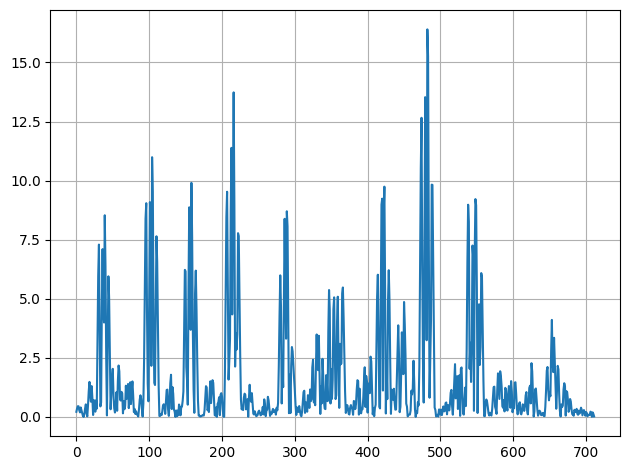

In [35]:
plt.plot(abs(dy))
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()

In [32]:
np.mean(signal_find_peaks1)  #2,5,2,1.5

9.28039051508137

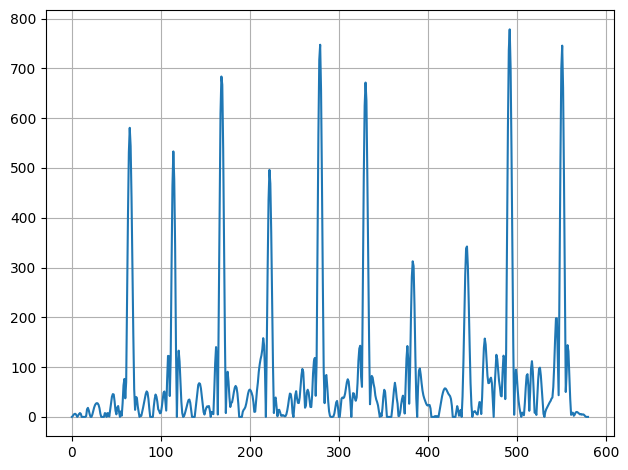

In [110]:
from scipy.signal import medfilt

signal = decim_signal_all_hand[7]
med = medfilt(signal, kernel_size=31)
detail = signal - med
#dy = np.gradient((detail))
#dy = np.where(dy>1, 1, dy)

plt.plot(np.abs(detail))
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()

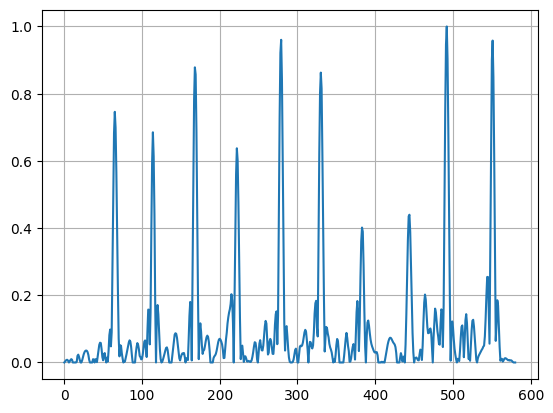

In [112]:
#signal_check = moving_average(abs(dyX),4)
signal_check = np.abs(detail)
signal_check = (signal_check/np.max(signal_check)) #
plt.plot(signal_check)
#plt.plot(dyX)
plt.grid()
plt.show()

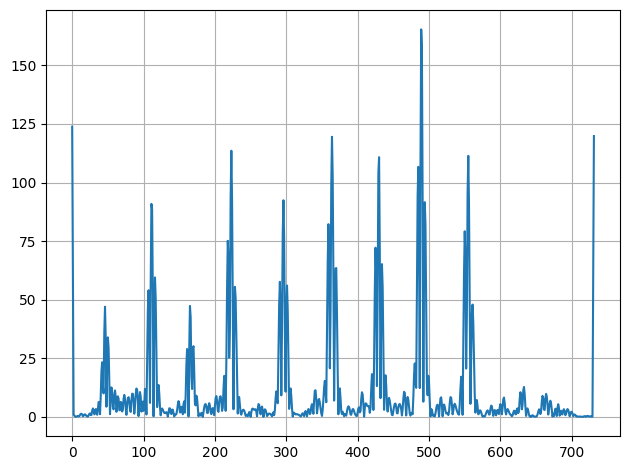

In [26]:
signal = decim_signal_all_hand[7]

# --- сглаживание ---
win = 5  # ширина окна — регулирует "степень сглаживания"
smooth = np.convolve(signal, np.ones(win)/win, mode='same')

# --- выделение пикового компонента ---
detail = signal - smooth

plt.plot(np.abs(detail))
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()

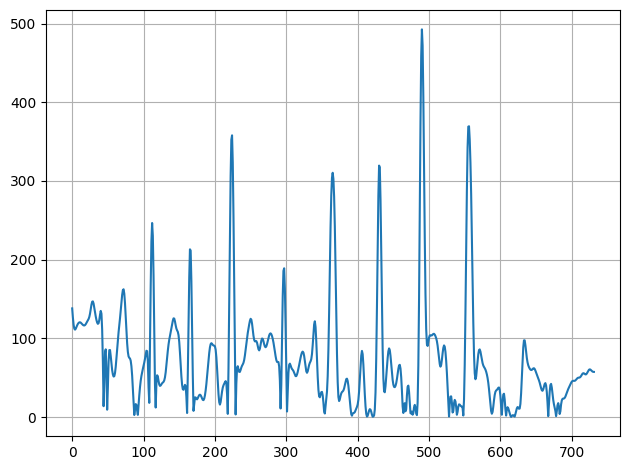

In [27]:
signal = decim_signal_all_hand[4]

detail = signal - np.mean(signal)

plt.plot(np.abs(detail))
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()